# First data exploration

This notebook contains the code to explore various datasets for the RSApp project.

Datasets include:
- a fire history (nr fires per year per pixel) image, with a raster for each year from 2001 to 2015, provided by [Global Forest Watch](https://data.globalforestwatch.org/datasets/indonesia-fire-history/about)
- **MODIS fire alerts** in Indonesia from 2001 to 2025, from NASA FIRMS
- shapefile of peatland areas from Global Forest Watch (not good according to Sasa) - maybe compare to PEATMAP and Global Peat Map
- 2021 global **land cover** map from ESA, cropped to Indonesia for classification into cropland vs. forest vs. shrubland
- global peatland map (published 2022) from [Global Peatlands](https://globalpeatlands.org/new-online-global-peatland-map-asian-peatlands-story-map-presenting-best-peatlands-mapping)

# Wildfire history Indonesia

In [1]:
import rasterio
import xarray as xr
import numpy as np
from rasterio.plot import show

In [38]:
import rioxarray

### Explore single raster (2001)

In [3]:
path = "input-data/fire-history-data/kd2001_rgb.tif"
fh_2001 = rasterio.open(path)

In [15]:
# Basic info on the raster dataset
print("Number of bands:", fh_2001.count)
print("Width (nr of pixels):", fh_2001.width)
print("Height (nr of pixels):", fh_2001.height)
print("CRS:", fh_2001.crs)
print("Bounding coordinates:", fh_2001.bounds)

Number of bands: 3
Width (nr of pixels): 9133
Height (nr of pixels): 3306
CRS: EPSG:4326
Bounding coordinates: BoundingBox(left=95.3435, bottom=-10.7195, right=141.0085, top=5.810500000000001)


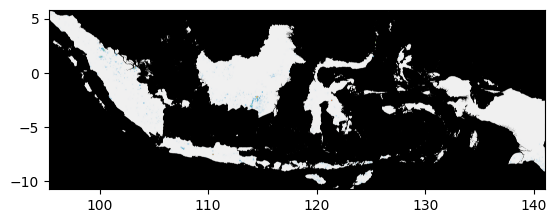

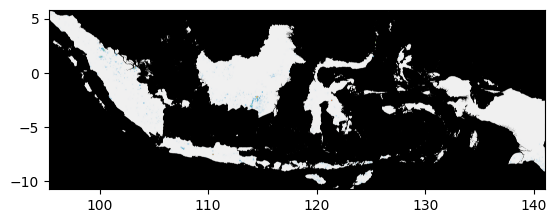

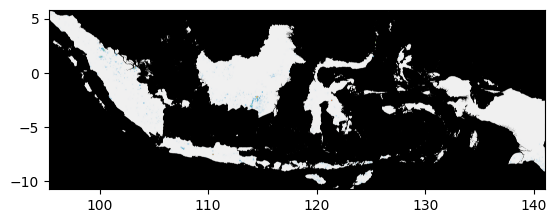

<Axes: >

In [20]:
# Display individual layers
show(fh_2001,1)
show(fh_2001,2)
show(fh_2001,3)

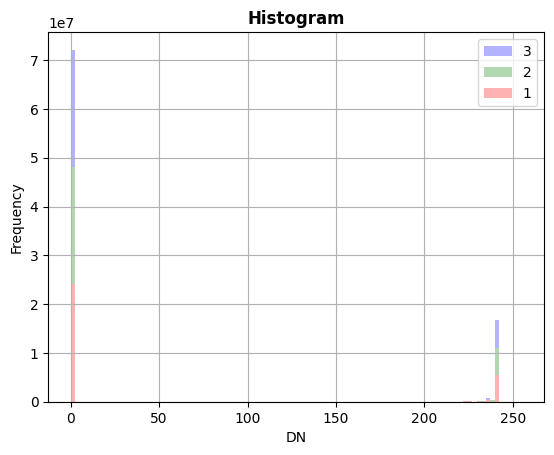

In [49]:
from rasterio.plot import show_hist

show_hist(fh_2001, 
          bins=100,
          lw=0.0, 
          stacked=True, 
          alpha=0.3,
          histtype='stepfilled', 
          title="Histogram")

#### Load all rasters as xarray

In [41]:
def load_yearly_rasters_rio(years, path_template="input-data/fire-history-data/kd{year}_rgb.tif"):
    """
    Load raster layers from different years and combine
    them into xarray object, with full spatial metadata preserved.

    Input:
    -----
    years : list or range
        years to load (e.g., range(2001, 2016))
    path_template : str
        path template with {year} placeholder

    Output:
    ------
    combined: xarray
        combined raster layers (yearly temporal resolution)
    """
    
    datasets = []
    
    for year in years:
        filepath = path_template.format(year=year)
        da = rioxarray.open_rasterio(filepath, masked=True)
        #da = da.squeeze('band', drop=True)  # Remove band dimension if single band
        da = da.assign_coords(time=year)
        datasets.append(da)
    
    # concatenate along time dimension
    combined = xr.concat(datasets, dim='time')
    return combined

# function developed by Claude AI

In [47]:
fh = load_yearly_rasters_rio(years=range(2001,2003))

In [44]:
rioxarray.open_rasterio("fire-history-data/kd2001_rgb.tif", masked=True)

<xarray.DataArray (band: 3, y: 3306, x: 9133)> Size: 362MB
[90581094 values with dtype=float32]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 73kB 95.35 95.35 95.36 95.36 ... 141.0 141.0 141.0
  * y            (y) float64 26kB 5.808 5.803 5.798 ... -10.71 -10.71 -10.72
    spatial_ref  int64 8B 0
Attributes:
    DataType:       Processed
    AREA_OR_POINT:  Area
    BandName:       Band_1
    scale_factor:   1.0
    add_offset:     0.0

Problem with this dataset: it is an RGB image, it does not show the actual data (how many fires) but only the color based on the category. Therefore, it is better to use the original data (see next section).

# MODIS fire alerts from NASA FIRMS
Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

In [9]:
import geopandas as gpd
import pandas as pd

In [2]:
modis_fa_path = "input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"

In [5]:
modis_fa = gpd.read_file(modis_fa_path)

In [18]:
# filter to only keep TYPE 0: presumed vegetation fire
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0].copy()

In [19]:
# add column with year
modis_fa_vf.loc[:,"YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})


In [32]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,YEAR
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),2001
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),2001
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),2001
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),2001
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),2001


232696


<Axes: >

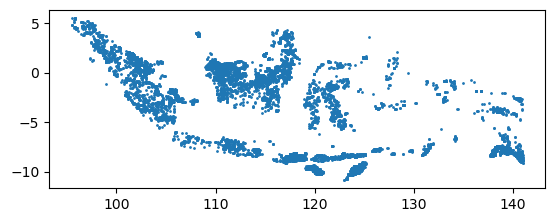

In [41]:
# plot fires in 2020
modis_fa_vf_2020 = modis_fa_vf[modis_fa_vf["YEAR"] == 2020]

print(modis_fa_vf_2020.size)

modis_fa_vf_2020.plot(markersize=1)

In [ ]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd

# Read shapefile
#modis_fa_path = "input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"
#fires = gpd.read_file(modis_fa_path)


### Rasterize (to xarray)

In [11]:
# see number of fire alters per year
modis_fa_vf.groupby("YEAR").size()

YEAR
2001     13295
2002    117986
2003     59568
2004    100792
2005     62853
2006    144501
2007     41315
2008     39317
2009     97215
2010     18983
2011     60238
2012     68572
2013     51914
2014    105057
2015    156133
2016     21978
2017     15701
2018     35496
2019     87141
2020     13688
2021     11815
2022      8983
2023     48216
2024     19458
2025      6114
dtype: int64

In [17]:
print(modis_fa_vf.ACQ_DATE.dtype)

# convert to datetime
#modis_fa_vf['ACQ_DATE'] = pd.to_datetime(modis_fa_vf['ACQ_DATE'])

#print(modis_fa_vf.ACQ_DATE.dtype)


datetime64[ms]
datetime64[ms]


In [56]:
# Set up grid (along lat, lon, and time dimension)

# define grid resolution and extent
resolution = 0.01  # degrees, 0.01 approx 1km
minx, miny, maxx, maxy = modis_fa_vf.total_bounds # get min and max lat and lon of fire points

# get array of all coordinates 
lons = np.arange(minx, maxx + resolution, resolution)
lats = np.arange(miny, maxy + resolution, resolution)

# for each fire alert point, get the index of the corresponding lon and lat
lon_indices = np.digitize(modis_fa_vf['LONGITUDE'], lons) - 1
lat_indices = np.digitize(modis_fa_vf['LATITUDE'], lats) - 1

# get dates
unique_dates = pd.DatetimeIndex(sorted(modis_fa_vf['ACQ_DATE'].unique()))

# Create a date to index mapping 
date_to_idx = {date.date(): idx for idx, date in enumerate(unique_dates)}
time_indices = modis_fa_vf['ACQ_DATE'].map(date_to_idx).values

# Create sparse representation using pandas groupby
fire_coords = pd.DataFrame({
    'time_idx': time_indices,
    'lat_idx': lat_indices,
    'lon_idx': lon_indices
})

# Count fires per cell per day
fire_counts = fire_coords.groupby(['time_idx', 'lat_idx', 'lon_idx']).size()

# Create empty array
fire_array = np.zeros((len(unique_dates), len(lats), len(lons)), dtype=np.int32)


<Axes: >

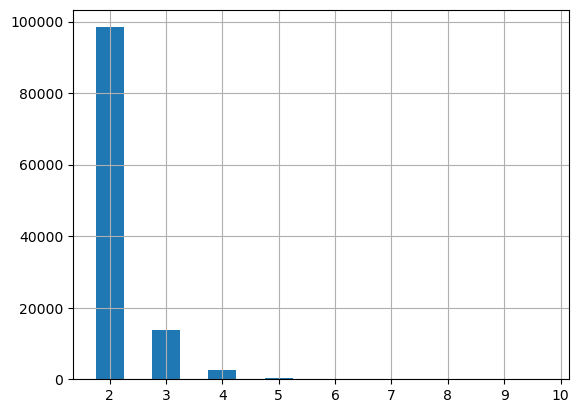

In [55]:
fire_counts.hist(bins=np.arange(1.75,10,0.5))

### Selection by buffer

In [58]:
# reproject to Web Mercator (in m)
modis_fa_vf_reproj = modis_fa_vf.copy().to_crs('EPSG:3857')

# replace geometry with buffer 
modis_fa_vf_reproj['geometry'] = modis_fa_vf_reproj.geometry.buffer(
    distance=500,       # meters
    cap_style="square"  # shape of buffer
)

In [66]:
modis_fa_vf_reproj2015 = modis_fa_vf_reproj[modis_fa_vf_reproj["YEAR"] == 2015]
modis_fa_vf_reproj_after2015 = modis_fa_vf_reproj[modis_fa_vf_reproj["YEAR"] > 2015]

only_2015 = modis_fa_vf_reproj2015.geometry.difference(modis_fa_vf_reproj_after2015.geometry, align=False)

print(only_2015.size)

only_2015.plot()

ValueError: Lengths of inputs do not match. Left: 156133, Right: 268590

# Indonesian peat lands

### Global Forest Watch (abandoned)

In [82]:
filepath_peatlands = "input-data/indonesia-peatlands/Indonesia_Peat_Lands.shp"
peatlands = gpd.read_file(filepath_peatlands)

In [83]:
peatlands.head()

,objectid_1,objectid,layer_revi,shape_leng,globalid,shape_Le_1,shape_Area,geometry
0,1,482,gambut,70789.064321,{DF27C432-2805-4FCF-8A7E-7E1DFD125C87},72528.694951,3.286301e+07,"MULTIPOLYGON Z (((14845286.338 -394955.138 0, ..."
1,2,483,gambut,3013.842302,{03DD8438-E728-49A1-9DEB-5997D38E1657},2996.905854,5.275723e+05,"POLYGON Z ((14893124.535 -393987.592 0, 148928..."
2,3,484,gambut,5750.073144,{356A5BD6-C249-4485-BB25-C99B383A708C},5635.047284,1.321287e+06,"POLYGON Z ((14797350.914 -393724.104 0, 147973..."
3,4,485,gambut,2027.459326,{0159915D-83EB-4B7C-AF71-AA67029CB67E},1912.760954,8.390727e+04,"POLYGON Z ((14891358.237 -393201.229 0, 148914..."
4,5,486,gambut,178017.496343,{82E80B91-9343-44BE-B9D5-119AD8FAE5C9},176121.923929,2.474371e+08,"POLYGON Z ((15554582.332 -395133.063 0, 155547..."


<Axes: >

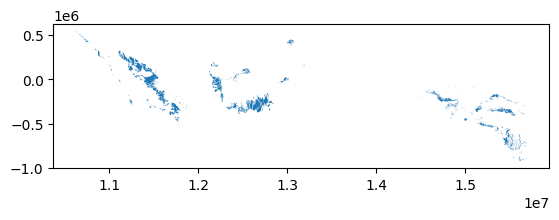

In [84]:
peatlands.plot(column="layer_revi")

### Global Peatlands

In [43]:
filepath_gp = "input-data/global-peatland-map/peatGPA22WGS_2cl.tif"

peatland_r = rasterio.open(filepath_gp)

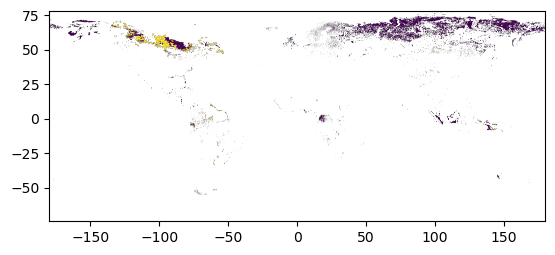

<Axes: >

In [44]:
# takes a long time to render (because global)
#rasterio.plot.show(peatland_r)

In [45]:
# Check basic information
print("Number of bands:", peatland_r.count)
print("Width (nr of pixels):", peatland_r.width)
print("Height (nr of pixels):", peatland_r.height)
print("CRS:", peatland_r.crs)
print("Bounding coordinates:", peatland_r.bounds)

Number of bands: 1
Width (nr of pixels): 36017
Height (nr of pixels): 15295
CRS: EPSG:4326
Bounding coordinates: BoundingBox(left=-179.766242816, bottom=-74.342809401, right=179.733393112, top=78.32251340541809)


In [47]:
np.unique(peatland_r.read(1))

array([  1,   2, 255], dtype=uint8)